In [1]:
import os
for root, dirs, files in os.walk("/kaggle/input/"):
    if files:
        print(f"📁 {root} — {len(files)} files")

📁 /kaggle/input/datasets/arkadeep2711/version2-test01 — 7 files
📁 /kaggle/input/datasets/arkadeep2711/version2-dataset/data/underbody/test/good — 784 files
📁 /kaggle/input/datasets/arkadeep2711/version2-dataset/data/underbody/test/anomaly — 402 files
📁 /kaggle/input/datasets/arkadeep2711/version2-dataset/data/underbody/train/good — 2058 files


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import os, cv2
from sklearn.model_selection import train_test_split
class UnderbodyDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(img), self.labels[idx]
normal_dir = "/kaggle/input/datasets/arkadeep2711/version2-dataset/data/underbody/train/good/"
anomaly_dir = "/kaggle/input/datasets/arkadeep2711/version2-dataset/data/underbody/test/anomaly/"
normal_paths = [os.path.join(normal_dir, f) for f in os.listdir(normal_dir) if cv2.imread(os.path.join(normal_dir, f)) is not None]
anomaly_paths = [os.path.join(anomaly_dir, f) for f in os.listdir(anomaly_dir) if cv2.imread(os.path.join(anomaly_dir, f)) is not None]
all_paths = normal_paths + anomaly_paths
all_labels = [0]*len(normal_paths) + [1]*len(anomaly_paths)
print(f"✅ Normal images  : {len(normal_paths)}")
print(f"✅ Anomaly images : {len(anomaly_paths)}")
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
train_loader = DataLoader(UnderbodyDataset(train_paths, train_labels, train_transform), batch_size=16, shuffle=True)
val_loader = DataLoader(UnderbodyDataset(val_paths, val_labels, val_transform), batch_size=16)
model = models.resnet50(weights="ResNet50_Weights.DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to("cuda")
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
best_val_acc = 0
for epoch in range(20):
    model.train()
    correct, total = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to("cuda"), labels.to("cuda")
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total * 100
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to("cuda"), labels.to("cuda")
            val_correct += (model(imgs).argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total * 100
    scheduler.step()
    print(f"Epoch {epoch+1}/20 | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print(f"  💾 Saved! Val Acc: {val_acc:.1f}%")
print(f"\n✅ Training complete! Best Val Accuracy: {best_val_acc:.1f}%")

✅ Normal images  : 2058
✅ Anomaly images : 402
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


Epoch 1/20 | Train Acc: 91.4% | Val Acc: 97.0%
  💾 Saved! Val Acc: 97.0%
Epoch 2/20 | Train Acc: 97.5% | Val Acc: 98.4%
  💾 Saved! Val Acc: 98.4%
Epoch 3/20 | Train Acc: 98.2% | Val Acc: 99.2%
  💾 Saved! Val Acc: 99.2%
Epoch 4/20 | Train Acc: 98.6% | Val Acc: 98.4%
Epoch 5/20 | Train Acc: 99.3% | Val Acc: 98.2%
Epoch 6/20 | Train Acc: 99.1% | Val Acc: 98.4%
Epoch 7/20 | Train Acc: 99.7% | Val Acc: 98.6%
Epoch 8/20 | Train Acc: 99.6% | Val Acc: 98.2%
Epoch 9/20 | Train Acc: 99.5% | Val Acc: 98.4%
Epoch 10/20 | Train Acc: 99.6% | Val Acc: 98.6%
Epoch 11/20 | Train Acc: 99.7% | Val Acc: 99.2%
Epoch 12/20 | Train Acc: 99.7% | Val Acc: 98.8%
Epoch 13/20 | Train Acc: 99.8% | Val Acc: 99.0%
Epoch 14/20 | Train Acc: 99.7% | Val Acc: 99.0%
Epoch 15/20 | Train Acc: 99.7% | Val Acc: 99.0%
Epoch 16/20 | Train Acc: 99.9% | Val Acc: 98.8%
Epoch 17/20 | Train Acc: 99.9% | Val Acc: 99.0%
Epoch 18/20 | Train Acc: 99.9% | Val Acc: 98.8%
Epoch 19/20 | Train Acc: 99.9% | Val Acc: 98.4%
Epoch 20/20 | Train

In [3]:
import torch, cv2, os
import torch.nn as nn
from torchvision import transforms, models
import matplotlib.pyplot as plt

model = models.resnet50(weights="ResNet50_Weights.DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/kaggle/working/best_model.pth", map_location="cuda", weights_only=False))
model = model.to("cuda")
model.eval()

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def predict_and_show(image_path):
    from PIL import Image
    import numpy as np
    try:
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except:
        img = np.array(Image.open(image_path).convert("RGB"))
    tensor = val_transform(img).unsqueeze(0).to("cuda")
    with torch.no_grad():
        output = model(tensor)
        prob = torch.softmax(output, dim=1)
        pred = output.argmax(1).item()
        confidence = prob[0][pred].item() * 100
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    if pred == 1:
        plt.title(f"⚠️ ANOMALY DETECTED\nConfidence: {confidence:.1f}%",
                  color="red", fontsize=12, fontweight="bold")
    else:
        plt.title(f"✅ NORMAL\nConfidence: {confidence:.1f}%",
                  color="green", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("✅ Ready!")

✅ Ready!


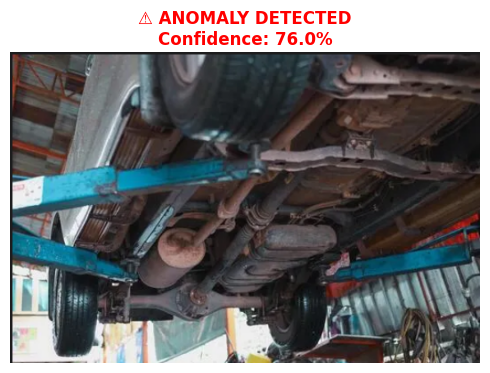

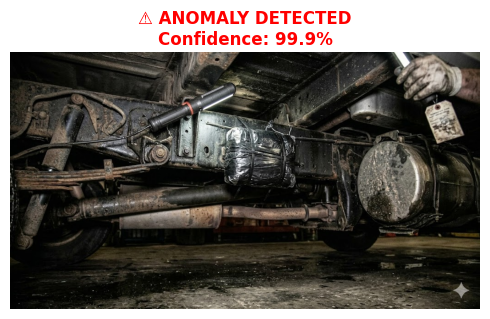

/tmp/ipykernel_23/3394295643.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


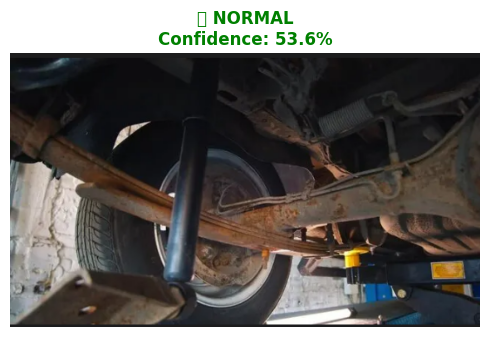

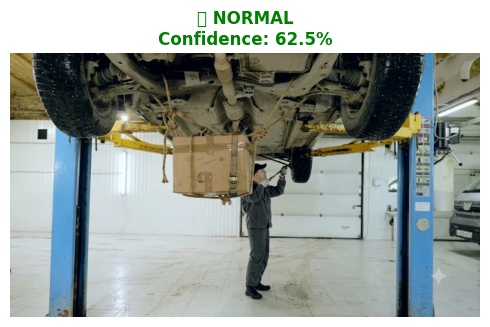

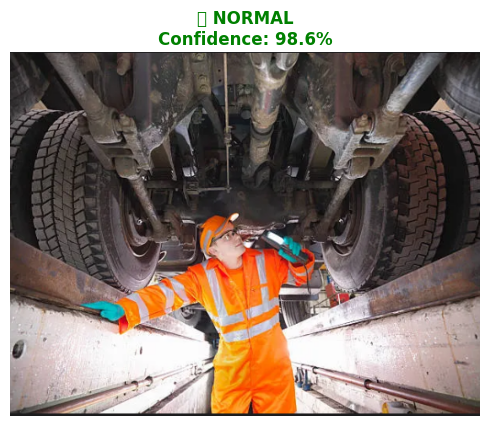

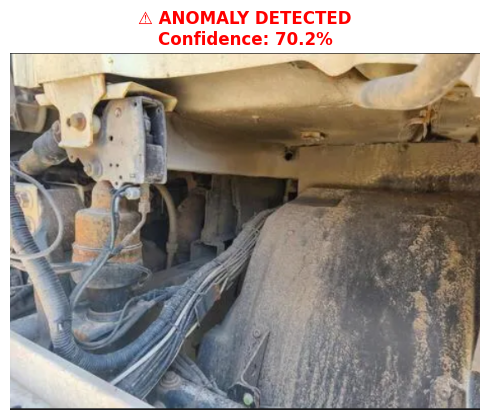

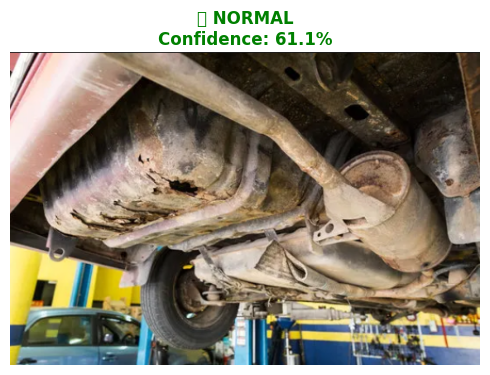

In [4]:
for root, dirs, files in os.walk("/kaggle/input/datasets/arkadeep2711/version2-test01/"):
    for f in files:
        if f.endswith(('.jpg', '.jpeg', '.png', '.jfif', '.PNG', '.webp')):
            predict_and_show(os.path.join(root, f))

In [5]:
import torch, json, os

# Save model
torch.save(model.state_dict(), "/kaggle/working/best_model_v2.pth")

# Save metadata
metadata = {
    "model": "resnet50",
    "version": "v2",
    "classes": {0: "normal", 1: "anomaly"},
    "input_size": [256, 256],
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],
    "best_val_accuracy": 99.0
}
with open("/kaggle/working/metadata_v2.json", "w") as f:
    json.dump(metadata, f)

# Verify
for f in os.listdir("/kaggle/working/"):
    if not f.startswith("."):
        size = os.path.getsize(f"/kaggle/working/{f}") / (1024*1024)
        print(f"📦 {f} — {size:.1f} MB")

print("\n✅ Ready to download!")

📦 best_model.pth — 90.0 MB
📦 metadata_v2.json — 0.0 MB
📦 best_model_v2.pth — 90.0 MB
📦 __notebook__.ipynb — 2.3 MB

✅ Ready to download!
